# Exploratory Data Analysis PaySim Fraud Detection Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## 1. Load the Data

In [ ]:
DATA_PATH = r"C:\Users\User\Desktop\fraud_data.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
# Drop isFlaggedFraud — it's a naive rule-based flag, not what we're predicting
df = df.drop(columns=['isFlaggedFraud'])

In [11]:
df.shape

(6362620, 10)

## 2. Basic Statistics

In [10]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [13]:
total_tx = len(df)
fraud_tx = df['isFraud'].sum()
fraud_pct = fraud_tx / total_tx * 100
unique_orig = df['nameOrig'].nunique()
unique_dest = df['nameDest'].nunique()
unique_accts = pd.concat([df['nameOrig'], df['nameDest']]).nunique()
time_steps = df['step'].nunique()

print(f'Total transactions : {total_tx:>12,}')
print(f'Fraudulent txns    : {fraud_tx:>12,}')
print(f'Fraud rate         : {fraud_pct:>11.3f}%')
print(f'Unique senders     : {unique_orig:>12,}')
print(f'Unique receivers   : {unique_dest:>12,}')
print(f'Unique accounts    : {unique_accts:>12,}')
print(f'Time steps (hours) : {time_steps:>12,}')

Total transactions :    6,362,620
Fraudulent txns    :        8,213
Fraud rate         :       0.129%
Unique senders     :    6,353,307
Unique receivers   :    2,722,362
Unique accounts    :    9,073,900
Time steps (hours) :          743


## 3. Fraud Class Distribution

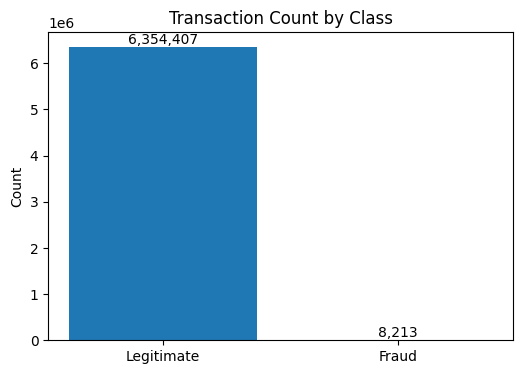

In [ ]:
counts = df['isFraud'].value_counts()
labels = ['Legitimate', 'Fraud']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts)
plt.title('Transaction Count by Class')
plt.ylabel('Count')

for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height()):,}', ha='center', va='bottom')

plt.show()

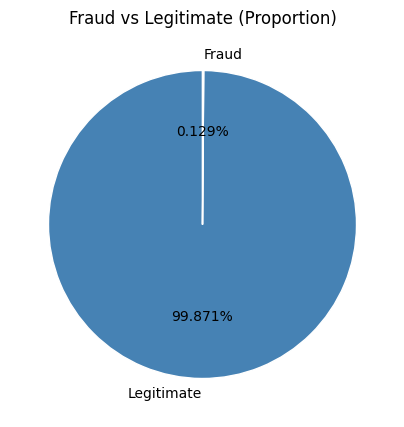

In [18]:
plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, colors=colors,
        autopct='%1.3f%%', startangle=90,
        wedgeprops={'edgecolor':'white'})
plt.title('Fraud vs Legitimate (Proportion)')
plt.show()

**Observation:** The dataset is extremely imbalanced. Fraud is only ~0.13% of all transactions. This means accuracy is a bad metric — we must use PR-AUC and Recall.

## 4. Transaction Types

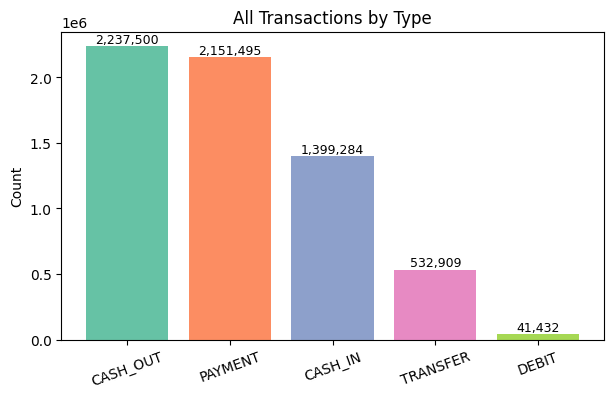

In [27]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(7,4))
bars = plt.bar(type_counts.index, type_counts,
               color=sns.color_palette('Set2', len(type_counts)))
plt.title('All Transactions by Type')
plt.ylabel('Count')
plt.xticks(rotation=20)

for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.show()

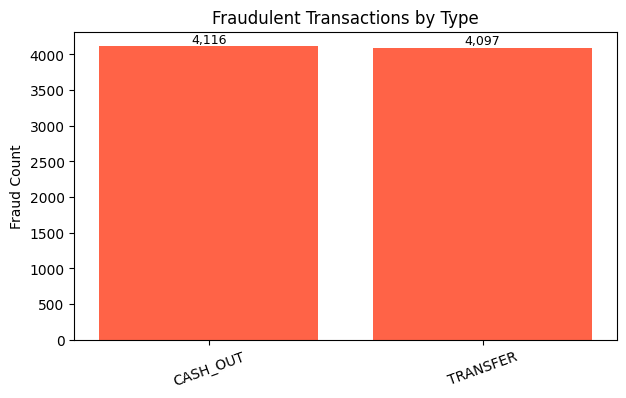

In [29]:
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
colors = ['tomato' if t in ['TRANSFER','CASH_OUT'] else 'lightcoral'
          for t in fraud_by_type.index]
plt.figure(figsize=(7,4))
bars = plt.bar(fraud_by_type.index, fraud_by_type, color=colors)
plt.title('Fraudulent Transactions by Type')
plt.ylabel('Fraud Count')
plt.xticks(rotation=20)

for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.show()

In [31]:
# Fraud rate per transaction type
fraud_rate_by_type = (df.groupby('type')['isFraud'].agg(['sum', 'count']).rename(columns={'sum': 'fraud_count', 'count': 'total_count'}))
fraud_rate_by_type['fraud_rate_%'] = (fraud_rate_by_type['fraud_count'] / fraud_rate_by_type['total_count'] * 100).round(3)

fraud_rate_by_type.sort_values('fraud_rate_%', ascending=False)

,fraud_count,total_count,fraud_rate_%
type,,,
TRANSFER,4097,532909,0.769
CASH_OUT,4116,2237500,0.184
CASH_IN,0,1399284,0.000
DEBIT,0,41432,0.000
PAYMENT,0,2151495,0.000


**Key insight:** Fraud only occurs in **TRANSFER** and **CASH_OUT** transaction types. This is a very strong signal — we can filter other types out for modeling if needed.

## 5. Transaction Amount Analysis

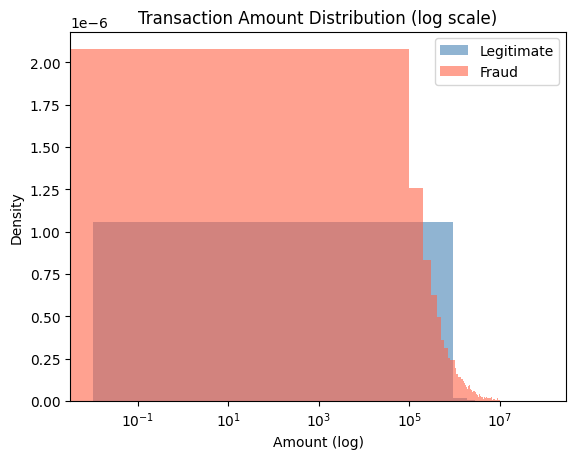

In [32]:
# Histogram (log scale)
plt.hist(df.loc[df['isFraud']==0, 'amount'], bins=100, alpha=0.6, label='Legitimate', color='steelblue', density=True)
plt.hist(df.loc[df['isFraud']==1, 'amount'], bins=100, alpha=0.6,label='Fraud', color='tomato', density=True)

plt.xscale('log')
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Amount (log)')
plt.ylabel('Density')
plt.legend()

plt.show()

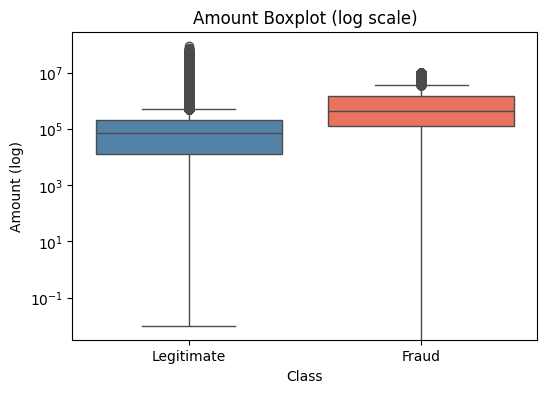

In [ ]:
df_box = df[['amount','isFraud']].copy()
df_box['Class'] = df_box['isFraud'].map({0:'Legitimate',1:'Fraud'})
sns.boxplot(data=df_box, x='Class', y='amount', palette=['steelblue','tomato'])

plt.yscale('log')
plt.title('Amount Boxplot (log scale)')
plt.ylabel('Amount (log)')
plt.show()

In [40]:
print('Amount stats by class:')
df.groupby('isFraud')['amount'].describe().round(2)

Amount stats by class:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,178197.04,596236.98,0.01,13368.40,74684.72,208364.76,92445516.64
1,8213.0,1467967.30,2404252.95,0.00,127091.33,441423.44,1517771.48,10000000.00


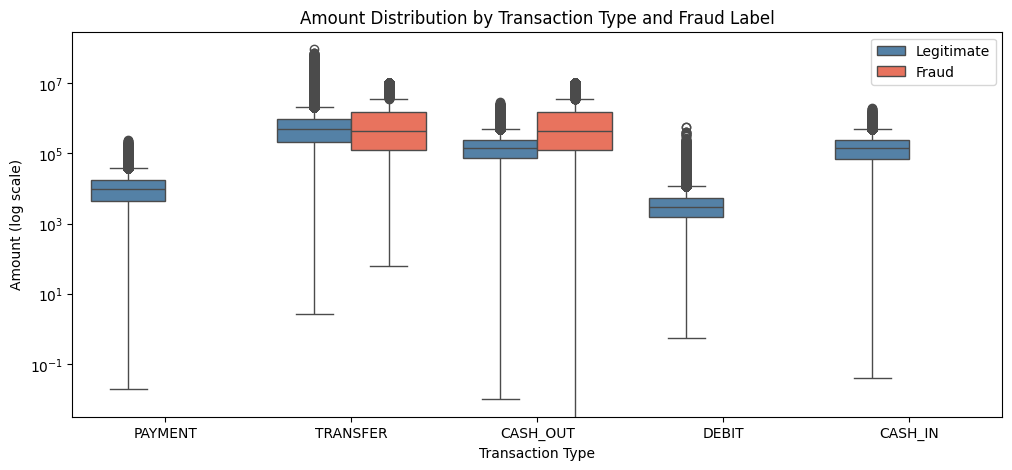

In [36]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='type', y='amount', hue='isFraud', palette={0: 'steelblue', 1: 'tomato'})
plt.yscale('log')
plt.title('Amount Distribution by Transaction Type and Fraud Label')
plt.ylabel('Amount (log scale)')
plt.xlabel('Transaction Type')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Legitimate', 'Fraud'])
plt.show()

## 6. Balance Analysis

Fraudulent transactions often drain accounts completely — let's check that.

In [ ]:
df['deltaOrig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['deltaDest'] = df['newbalanceDest'] - df['oldbalanceDest']

zero_balance_fraud = (df[df['isFraud'] == 1]['newbalanceOrig'] == 0).mean() * 100
zero_balance_legit = (df[df['isFraud'] == 0]['newbalanceOrig'] == 0).mean() * 100

print(f'Sender ends with zero balance — Fraud: {zero_balance_fraud:.1f}%')
print(f'Sender ends with zero balance — Legit: {zero_balance_legit:.1f}%')

Sender ends with zero balance — Fraud: 98.1%
Sender ends with zero balance — Legit: 56.7%


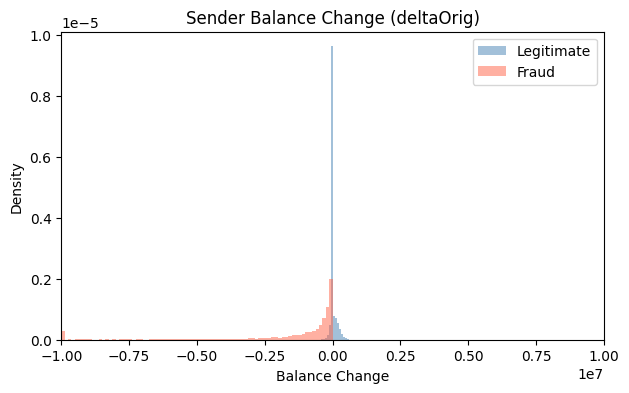

In [43]:
plt.figure(figsize=(7,4))
plt.hist(df.loc[df['isFraud']==0, 'deltaOrig'], bins=80, alpha=0.5, label='Legitimate', color='steelblue', density=True)
plt.hist(df.loc[df['isFraud']==1, 'deltaOrig'], bins=80, alpha=0.5, label='Fraud', color='tomato', density=True)

plt.title('Sender Balance Change (deltaOrig)')
plt.xlabel('Balance Change')
plt.ylabel('Density')
plt.xlim(-1e7, 1e7)
plt.legend()

plt.show()

In [45]:
suspicious = df[
    (df['type'].isin(['TRANSFER', 'CASH_OUT'])) &
    (df['deltaDest'] == 0) &
    (df['amount'] > 0)
]

print(f'Suspicious (amount > 0, receiver balance unchanged): {len(suspicious):,} transactions')
print(f'  Of which fraud: {suspicious["isFraud"].sum():,} ({suspicious["isFraud"].mean()*100:.1f}%)')

Suspicious (amount > 0, receiver balance unchanged): 5,776 transactions
  Of which fraud: 4,070 (70.5%)


**Interesting:** Cases where money is transferred but the receiver's balance doesn't increase. This could indicate accounts that are quickly drained again or data inconsistencies — worth exploring.

## 7. Temporal Patterns

In [46]:
tx_per_step = df.groupby('step').size().rename('total')
fraud_per_step = df.loc[df['isFraud']==1].groupby('step').size().rename('fraud')

temporal = pd.concat([tx_per_step, fraud_per_step], axis=1).fillna(0)
temporal['fraud_rate'] = temporal['fraud'] / temporal['total'] * 100

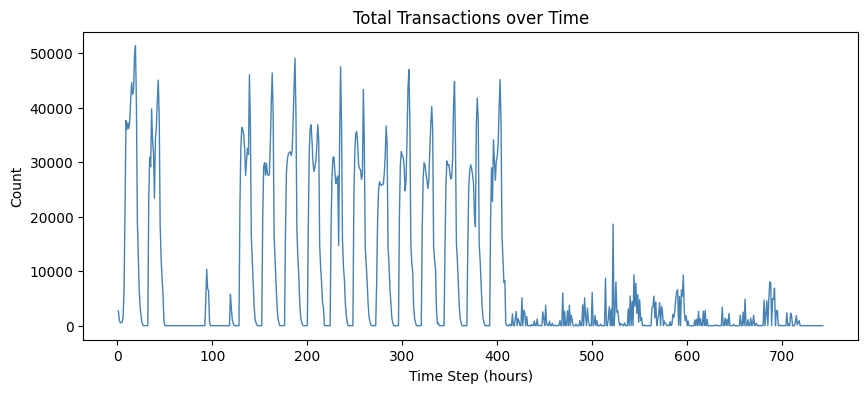

In [47]:
plt.figure(figsize=(10,4))

plt.plot(temporal.index, temporal['total'],
         color='steelblue', lw=1)

plt.title('Total Transactions over Time')
plt.ylabel('Count')
plt.xlabel('Time Step (hours)')

plt.show()

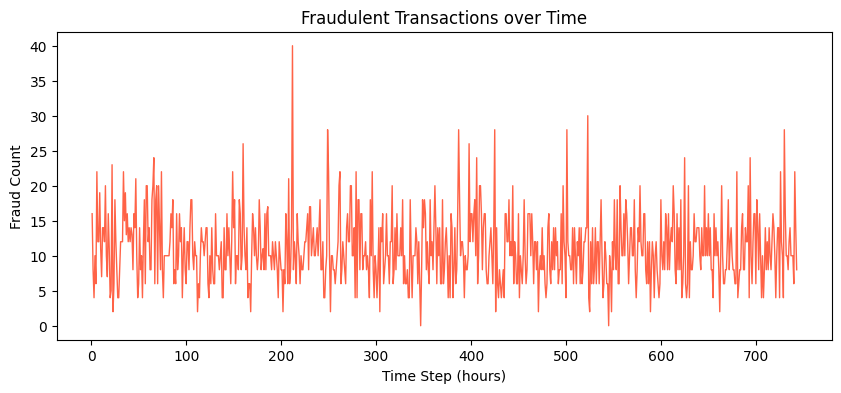

In [48]:
plt.figure(figsize=(10,4))

plt.plot(temporal.index, temporal['fraud'],
         color='tomato', lw=1)

plt.title('Fraudulent Transactions over Time')
plt.ylabel('Fraud Count')
plt.xlabel('Time Step (hours)')

plt.show()

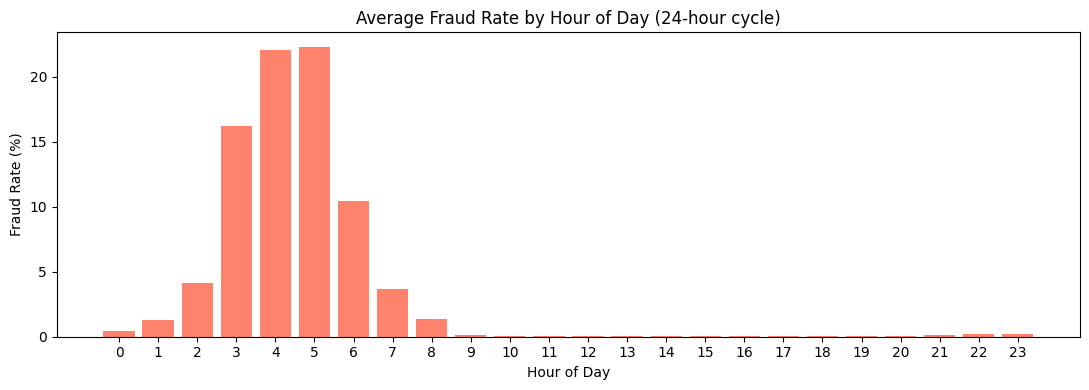

In [51]:
df['hour_of_day'] = df['step'] % 24
hourly_fraud_rate = df.groupby('hour_of_day')['isFraud'].mean() * 100
plt.figure(figsize=(11,4))

plt.bar(hourly_fraud_rate.index,
        hourly_fraud_rate,
        color='tomato',
        alpha=0.8)

plt.title('Average Fraud Rate by Hour of Day (24-hour cycle)')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

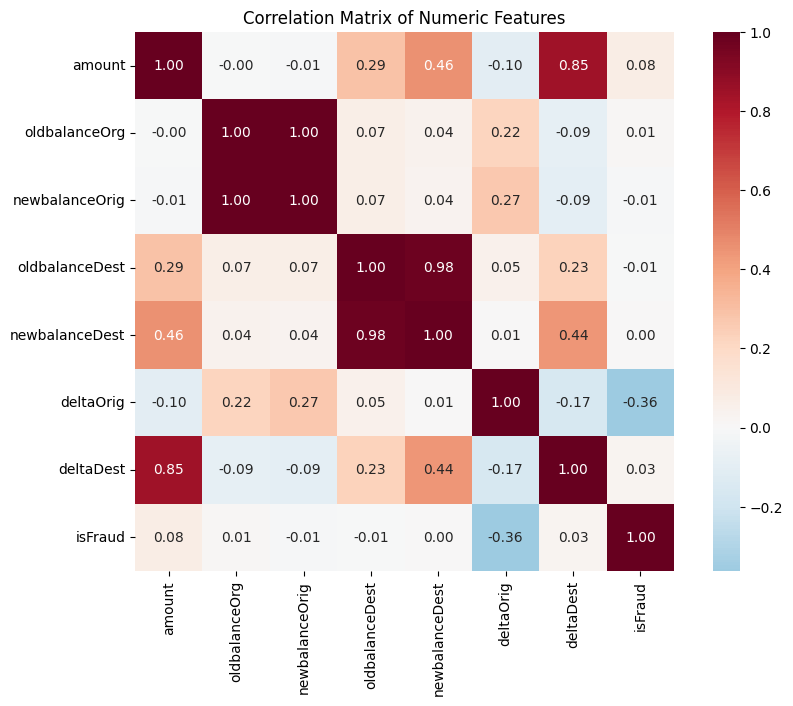

In [54]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True
)

plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [55]:
print('Correlation with isFraud:')

df.corr(numeric_only=True)['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False)

Correlation with isFraud:


deltaOrig        -0.362472
amount            0.076688
step              0.031578
hour_of_day      -0.031403
deltaDest         0.027028
oldbalanceOrg     0.010154
newbalanceOrig   -0.008148
oldbalanceDest   -0.005885
newbalanceDest    0.000535
Name: isFraud, dtype: float64

## 9. Graph Perspective — Accounts & Degrees

Let's take a quick look at the network structure without building the full graph.

In [57]:
print('Out-degree stats (senders):')
print(df.groupby('nameOrig').size().describe().round(2))

print('\nIn-degree stats (receivers):')
print(df.groupby('nameDest').size().describe().round(2))

Out-degree stats (senders):
count    6353307.00
mean           1.00
std            0.04
min            1.00
25%            1.00
50%            1.00
75%            1.00
max            3.00
dtype: float64

In-degree stats (receivers):
count    2722362.00
mean           2.34
std            4.55
min            1.00
25%            1.00
50%            1.00
75%            1.00
max          113.00
dtype: float64


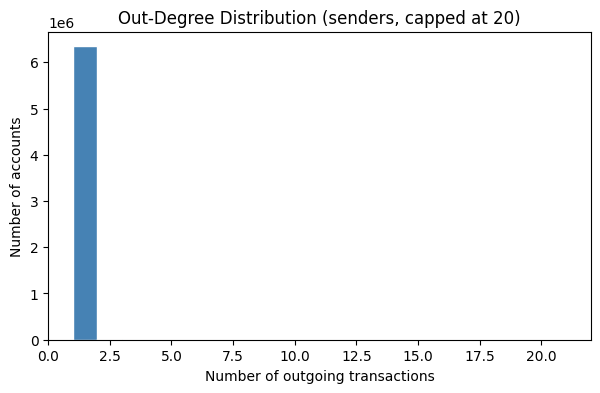

In [58]:
out_deg_cap = out_deg.clip(upper=20)

plt.figure(figsize=(7,4))
plt.hist(out_deg_cap, bins=range(1,22),
         color='steelblue', edgecolor='white')

plt.title('Out-Degree Distribution (senders, capped at 20)')
plt.xlabel('Number of outgoing transactions')
plt.ylabel('Number of accounts')

plt.show()

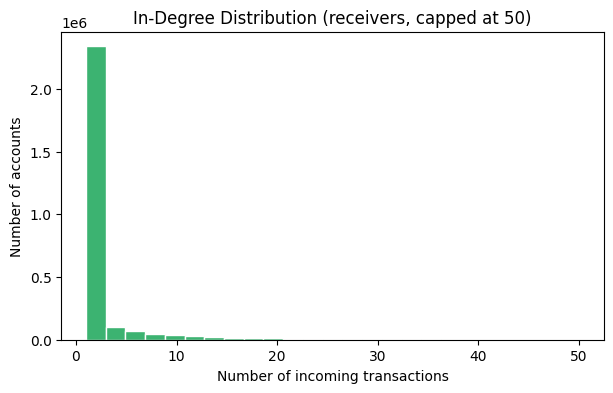

In [59]:
in_deg_cap = in_deg.clip(upper=50)

plt.figure(figsize=(7,4))
plt.hist(in_deg_cap, bins=25,
         color='mediumseagreen', edgecolor='white')

plt.title('In-Degree Distribution (receivers, capped at 50)')
plt.xlabel('Number of incoming transactions')
plt.ylabel('Number of accounts')

plt.show()